In [ ]:
# Tensorflow Approach
# 02_cnnlstm_training.ipynb
# Multiclass Attack Classification using CNN-LSTM on TPU
# ============================================================

# ── CELL 1: Mount Drive & Install Dependencies ───────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy -q

# ── CELL 2: GPU Setup ────────────────────────────────────────
import tensorflow as tf
import os

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU found: {gpus}")
    strategy = tf.distribute.OneDeviceStrategy('/gpu:0')
else:
    print("⚠️ No GPU found, running on CPU")
    strategy = tf.distribute.get_strategy()

print(f"TensorFlow version: {tf.__version__}")

# ── CELL 3: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")

# ── CELL 4: Paths & Config ───────────────────────────────────
train_csv  = "/content/drive/MyDrive/EPdataset/stratified_splits/train.csv"
test_csv   = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"
xgb_dir    = "/content/drive/MyDrive/EPdataset/models/xgboost"
output_dir = "/content/drive/MyDrive/EPdataset/models/cnnlstm"
plots_dir  = "/content/drive/MyDrive/EPdataset/plots/cnnlstm"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir,  exist_ok=True)

FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'L4_DST_PORT', 'ICMP_TYPE', 'DNS_QUERY_TYPE', 'DNS_QUERY_ID',
    'FTP_COMMAND_RET_CODE'
]
TARGET     = 'Attack'
SEQ_LEN    = 20
BATCH_SIZE = 512
print(f"Batch size: {BATCH_SIZE}")

# ── CELL 5: Load Scaler from XGBoost ─────────────────────────
scaler_path = os.path.join(xgb_dir, 'scaler.pkl')
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print("Scaler loaded from XGBoost output.")

# ── CELL 6: Build Sequences from Attack Rows Only ────────────
def build_sequences(csv_path, scaler, seq_len, label_encoder=None, fit_encoder=False):
    """
    Reads CSV in chunks, filters attack rows only,
    groups by attack type, builds non-overlapping sequences of seq_len rows.
    """
    print(f"\nBuilding sequences from {csv_path}...")

    attack_buffer = {}
    chunk_size = 1_000_000
    total_attack_rows = 0

    for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False)):
        chunk = chunk[chunk['Label'] == 1]
        total_attack_rows += len(chunk)

        for attack_type, group in chunk.groupby(TARGET):
            if attack_type not in attack_buffer:
                attack_buffer[attack_type] = []
            attack_buffer[attack_type].append(group[FEATURES].values)

        print(f"  Chunk {i+1} processed | Attack rows so far: {total_attack_rows:,}")

    print("\nBuilding sequences per attack type...")
    X_list = []
    y_list = []

    for attack_type, arrays in attack_buffer.items():
        rows = np.concatenate(arrays, axis=0)
        rows = scaler.transform(rows)

        n_sequences = len(rows) // seq_len
        if n_sequences == 0:
            print(f"  ⚠️  SKIPPED {attack_type}: only {len(rows)} rows (need at least {seq_len})")
            continue

        rows = rows[:n_sequences * seq_len]
        sequences = rows.reshape(n_sequences, seq_len, len(FEATURES))

        X_list.append(sequences)
        y_list.extend([attack_type] * n_sequences)
        print(f"  {attack_type:20s}: {len(rows):>10,} rows → {n_sequences:>8,} sequences")

    X = np.concatenate(X_list, axis=0)
    y_raw = np.array(y_list)

    if fit_encoder:
        label_encoder = LabelEncoder()
        label_encoder.fit(y_raw)

    y = label_encoder.transform(y_raw)

    print(f"\nTotal sequences : {len(X):,}")
    print(f"Sequence shape  : {X.shape}")
    return X, y, label_encoder


# Build train sequences and fit label encoder
X_train, y_train, label_encoder = build_sequences(
    train_csv, scaler, SEQ_LEN, fit_encoder=True
)

# Save label encoder
le_path = os.path.join(output_dir, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"\nLabel encoder saved.")
print(f"Classes: {list(label_encoder.classes_)}")

# Build test sequences
X_test, y_test, _ = build_sequences(
    test_csv, scaler, SEQ_LEN,
    label_encoder=label_encoder,
    fit_encoder=False
)

NUM_CLASSES = len(label_encoder.classes_)
print(f"\nNumber of attack classes: {NUM_CLASSES}")

# ── CELL 7: Class Weights & One-Hot Encoding ─────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print("\nClass weights:")
for idx, weight in class_weights.items():
    print(f"  {label_encoder.classes_[idx]:20s}: {weight:.4f}")

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train_cat.shape}")
print(f"y_test shape  : {y_test_cat.shape}")

# ── CELL 8: Build CNN-LSTM Model ─────────────────────────────
def build_cnnlstm(seq_len, n_features, n_classes):
    model = Sequential([
        # CNN block — extract local patterns
        Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # LSTM block — capture temporal dependencies
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # Classification head
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build model inside TPU strategy scope
with strategy.scope():
    model = build_cnnlstm(SEQ_LEN, len(FEATURES), NUM_CLASSES)

model.summary()

# ── CELL 9: Callbacks ────────────────────────────────────────
# Note: Save to local first, TPU cannot write directly to Drive
checkpoint_path = "/content/best_model.keras"

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ── CELL 10: Train ───────────────────────────────────────────
print("\nStarting CNN-LSTM training...")
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Copy best model to Drive
import shutil
shutil.copy(checkpoint_path, os.path.join(output_dir, 'best_model.keras'))
print("Best model copied to Drive.")

# ── CELL 11: Training History Plots ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN-LSTM — Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN-LSTM — Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'training_history.png'), dpi=150)
plt.show()
print("Training history saved.")

# ── CELL 12: Predictions ─────────────────────────────────────
print("\nGenerating predictions...")
y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)

# ── CELL 13: Core Metrics ────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
auc_score = roc_auc_score(
    y_test_cat, y_pred_proba,
    multi_class='ovr', average='macro'
)

print("\n========== CNN-LSTM Evaluation ==========")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

metrics_path = os.path.join(plots_dir, 'metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("========== CNN-LSTM Evaluation ==========\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write(f"AUC-ROC   : {auc_score:.4f}\n\n")
    f.write(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))
print(f"Metrics saved to {metrics_path}")

# ── CELL 14: Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('CNN-LSTM — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix.png'), dpi=150)
plt.show()
print("Confusion matrix saved.")

# ── CELL 15: AUC-ROC Curve (per class) ───────────────────────
plt.figure(figsize=(14, 8))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred_proba[:, i])
    auc_i = roc_auc_score(y_test_cat[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, lw=1.5, label=f'{class_name} (AUC={auc_i:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN-LSTM — AUC-ROC Curve (Per Class)', fontsize=14)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_roc_curve.png'), dpi=150)
plt.show()
print("AUC-ROC curve saved.")

# ── CELL 16: AUC-PR Curve (per class) ────────────────────────
plt.figure(figsize=(14, 8))
for i, class_name in enumerate(label_encoder.classes_):
    prec_vals, rec_vals, _ = precision_recall_curve(
        y_test_cat[:, i], y_pred_proba[:, i]
    )
    ap = average_precision_score(y_test_cat[:, i], y_pred_proba[:, i])
    plt.plot(rec_vals, prec_vals, lw=1.5, label=f'{class_name} (AP={ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('CNN-LSTM — Precision-Recall Curve (Per Class)', fontsize=14)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_pr_curve.png'), dpi=150)
plt.show()
print("AUC-PR curve saved.")

print("\n✅ CNN-LSTM training complete. All outputs saved to Drive.")

In [2]:
# ── CELL 1: Mount Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── CELL 2: Set JAX backend BEFORE any other imports ─────────
import os
os.environ['KERAS_BACKEND'] = 'jax'

# ── CELL 3: Install correct versions ─────────────────────────
!pip install -q keras jax[tpu] -f https://storage.googleapis.com/jax-releases/libtpu_releases.html
!pip install -q scikit-learn matplotlib seaborn pandas numpy

# ── CELL 4: Verify JAX sees TPU ──────────────────────────────
import jax

print(f"JAX version    : {jax.__version__}")
print(f"JAX backend    : {jax.default_backend()}")
print(f"JAX devices    : {jax.devices()}")
print(f"Device count   : {jax.device_count()}")

import keras
print(f"Keras version  : {keras.__version__}")
print(f"Keras backend  : {keras.backend}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JAX version    : 0.7.2
JAX backend    : tpu
JAX devices    : [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Device count   : 1
Keras version  : 3.13.2
Keras backend  : <module 'keras.backend' from '/usr/local/lib/python3.12/dist-packages/keras/backend/__init__.py'>


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JAX version    : 0.7.2
JAX backend    : tpu
JAX devices    : [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Keras version  : 3.13.2
Keras backend  : <module 'keras.backend' from '/usr/local/lib/python3.12/dist-packages/keras/backend/__init__.py'>
Scaler loaded.

Building sequences from /content/drive/MyDrive/EPdataset/stratified_splits/train.csv...
  Chunk 1 | Attack rows: 668,941
  Chunk 2 | Attack rows: 1,338,087
  Chunk 3 | Attack rows: 2,007,235
  Chunk 4 | Attack rows: 2,676,173
  Chunk 5 | Attack rows: 3,345,236
  Chunk 6 | Attack rows: 4,014,438
  Chunk 7 | Attack rows: 4,681,884
  Chunk 8 | Attack rows: 5,350,646
  Chunk 9 | Attack rows: 6,019,806
  Chunk 10 | Attack rows: 6,688,611
  Chunk 11 | Attack rows: 7,357,589
  Chunk 12 | Attack rows: 8,026,078
  Chunk 13 | Attack rows: 8,694,861
  Chunk 14 | Attack rows: 9,364,530
  Chunk

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  DDoS                :  761,192 sequences


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  DoS                 :  625,645 sequences
  Exploits            :    1,104 sequences
  Fuzzers             :      780 sequences
  Generic             :      579 sequences
  Infilteration       :    4,072 sequences
  Reconnaissance      :   92,182 sequences
  Shellcode           :       49 sequences
  Theft               :       85 sequences
  Worms               :        5 sequences
  injection           :   23,971 sequences
  mitm                :      270 sequences


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 64)         │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,020 (843.83 KB)

 Trainable params: 215,636 (842.33 KB)

 Non-trainable params: 384 (1.50 KB)


Starting CNN-LSTM training on TPU...
Epoch 1/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9046 - loss: 1.2518
Epoch 1: val_loss improved from None to 0.00925, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
869/869 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9669 - loss: 0.7348 - val_accuracy: 0.9980 - val_loss: 0.0092
Epoch 2/50
859/869 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9887 - loss: 0.4144
Epoch 2: val_loss improved from 0.00925 to 0.00656, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9908 - loss: 0.3468 - val_accuracy: 0.9981 - val_loss: 0.0066
Epoch 3/50
853/869 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9951 - loss: 0.1872
Epoch 3: val_loss improved from 0.00656 to 0.00489, saving model to /content/best_model.keras

Epoch 3: finished saving model to /content/best_model.keras
869/86

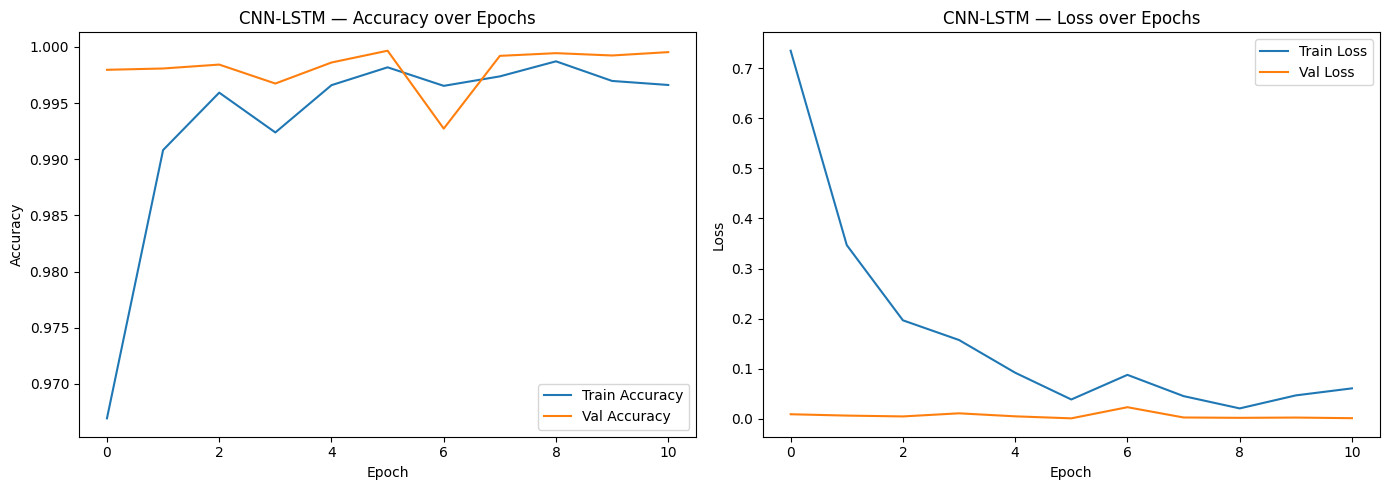

Training history saved.

Generating predictions...
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

========== CNN-LSTM Evaluation ==========
Accuracy  : 0.9997
Precision : 0.9997
Recall    : 0.9997
F1 Score  : 0.9997
AUC-ROC   : 1.0000

Classification Report:
                precision    recall  f1-score   support

      Analysis       0.64      1.00      0.78        34
      Backdoor       1.00      1.00      1.00       284
           Bot       1.00      1.00      1.00      2146
   Brute Force       1.00      1.00      1.00      1859
          DDoS       1.00      1.00      1.00    326225
           DoS       1.00      1.00      1.00    268133
      Exploits       0.98      0.98      0.98       473
       Fuzzers       0.95      0.97      0.96       334
       Generic       1.00      1.00      1.00       248
 Infilteration       0.99      0.99      0.99      1745
Reconnaissance       1.00      1.00      1.00     39506
     Shellcode       1.00      1.00      1.00        21
         Theft   

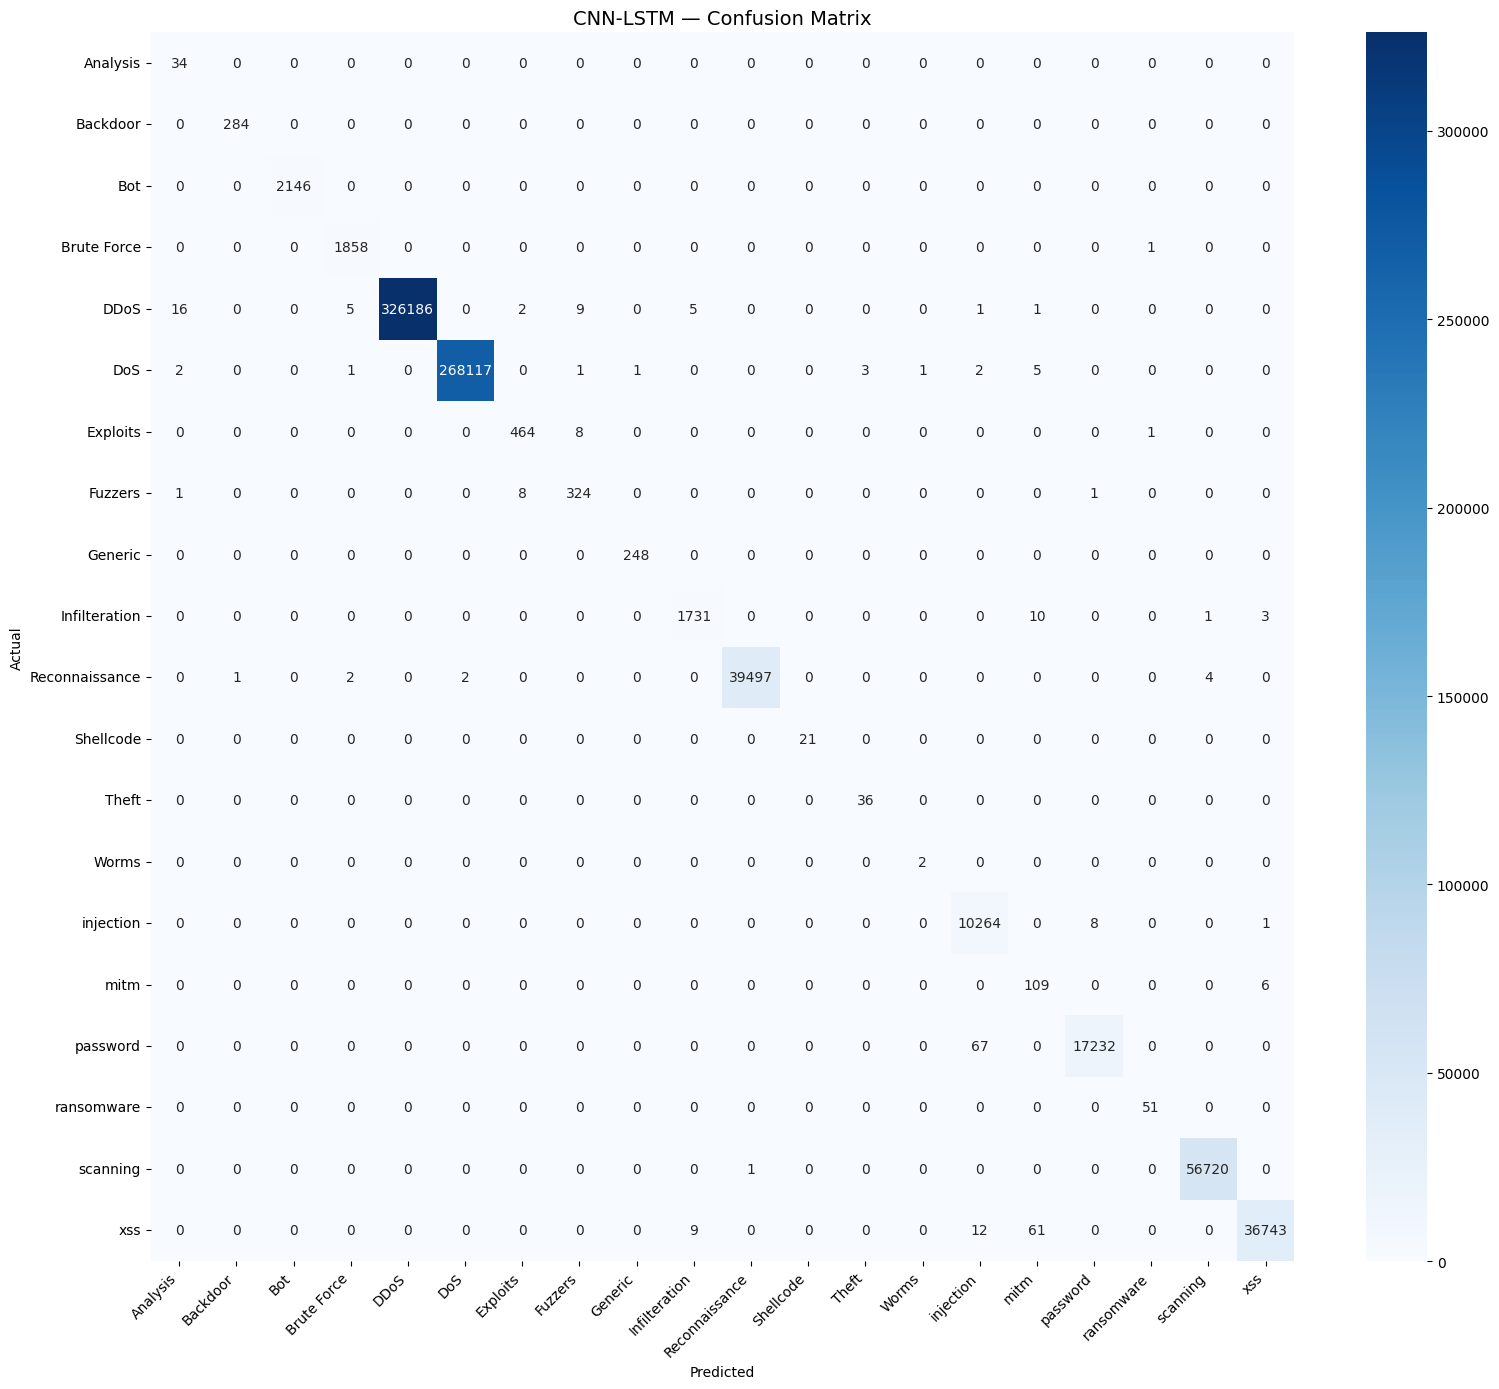

Confusion matrix saved.


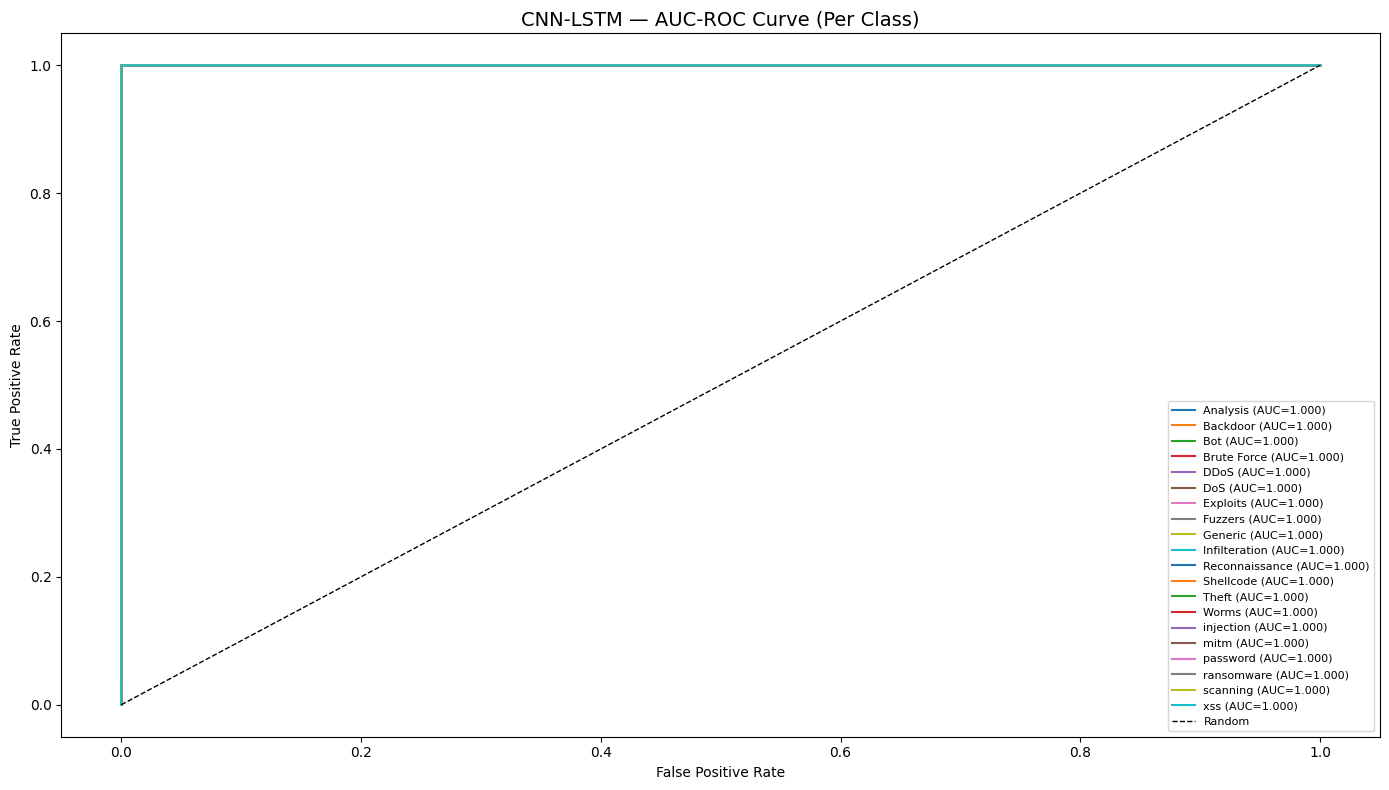

AUC-ROC curve saved.


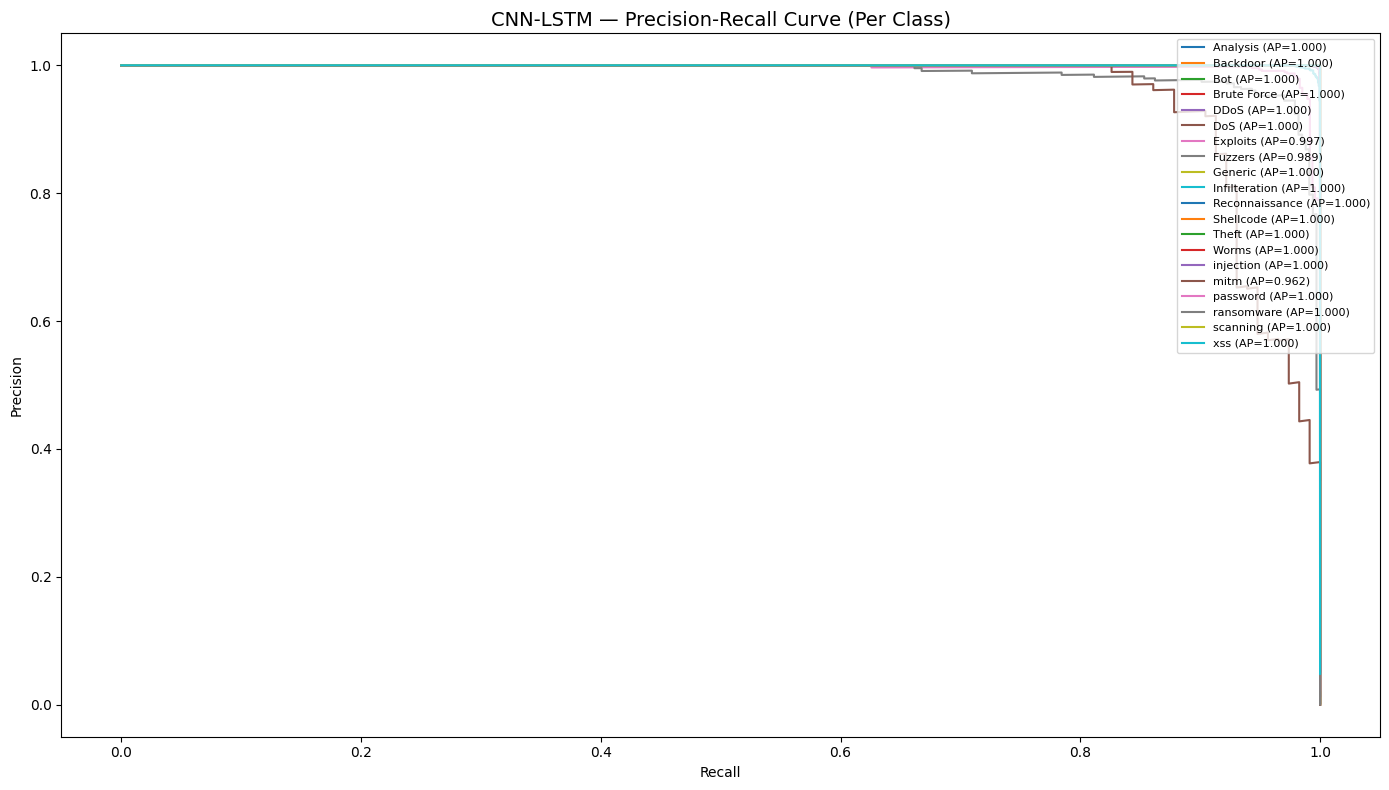

AUC-PR curve saved.

✅ CNN-LSTM training complete. All outputs saved to Drive.


In [3]:
# JAX Approach
# 02_cnnlstm_training.ipynb
# Multiclass Attack Classification using CNN-LSTM
# JAX backend + Keras 3 on v5e-1 TPU
# ============================================================

# ── CELL 1: Mount Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── CELL 2: Set JAX backend BEFORE any other imports ─────────
import os
os.environ['KERAS_BACKEND'] = 'jax'

# ── CELL 3: Install Dependencies ─────────────────────────────
!pip install -q keras jax[tpu] -f https://storage.googleapis.com/jax-releases/libtpu_releases.html
!pip install -q scikit-learn matplotlib seaborn pandas numpy

# ── CELL 4: Verify JAX + TPU ─────────────────────────────────
import jax
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print(f"JAX version    : {jax.__version__}")
print(f"JAX backend    : {jax.default_backend()}")
print(f"JAX devices    : {jax.devices()}")
print(f"Keras version  : {keras.__version__}")
print(f"Keras backend  : {keras.backend}")

from keras import layers, models, callbacks, utils
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

# ── CELL 5: Paths & Config ───────────────────────────────────
train_csv  = "/content/drive/MyDrive/EPdataset/stratified_splits/train.csv"
test_csv   = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"
xgb_dir    = "/content/drive/MyDrive/EPdataset/models/xgboost"
output_dir = "/content/drive/MyDrive/EPdataset/models/cnnlstm"
plots_dir  = "/content/drive/MyDrive/EPdataset/plots/cnnlstm"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir,  exist_ok=True)

FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'L4_DST_PORT', 'ICMP_TYPE', 'DNS_QUERY_TYPE', 'DNS_QUERY_ID',
    'FTP_COMMAND_RET_CODE'
]
TARGET     = 'Attack'
SEQ_LEN    = 20
BATCH_SIZE = 2048  # TPU loves large batches

# ── CELL 6: Load Scaler ──────────────────────────────────────
scaler_path = os.path.join(xgb_dir, 'scaler.pkl')
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print("Scaler loaded.")

# ── CELL 7: Build Sequences ──────────────────────────────────
def build_sequences(csv_path, scaler, seq_len,
                    label_encoder=None, fit_encoder=False):
    """
    Reads CSV in chunks, filters attack rows only,
    groups by attack type, builds non-overlapping sequences.
    With 47GB RAM all sequences fit in memory at once.
    """
    print(f"\nBuilding sequences from {csv_path}...")

    attack_buffer = {}
    chunk_size = 1_000_000
    total_attack_rows = 0

    for i, chunk in enumerate(pd.read_csv(
            csv_path, chunksize=chunk_size, low_memory=False)):
        chunk = chunk[chunk['Label'] == 1]
        total_attack_rows += len(chunk)

        for attack_type, group in chunk.groupby(TARGET):
            if attack_type not in attack_buffer:
                attack_buffer[attack_type] = []
            attack_buffer[attack_type].append(group[FEATURES].values)

        print(f"  Chunk {i+1} | Attack rows: {total_attack_rows:,}")

    # Fit label encoder
    if fit_encoder:
        label_encoder = LabelEncoder()
        label_encoder.fit(list(attack_buffer.keys()))

    X_list = []
    y_list = []

    print("\nBuilding sequences per attack type...")
    for attack_type, arrays in attack_buffer.items():
        rows = np.concatenate(arrays, axis=0)
        rows = scaler.transform(rows).astype(np.float32)

        n_sequences = len(rows) // seq_len
        if n_sequences == 0:
            print(f"  ⚠️  SKIPPED {attack_type}: only {len(rows)} rows")
            continue

        rows = rows[:n_sequences * seq_len]
        sequences = rows.reshape(n_sequences, seq_len, len(FEATURES))

        label = label_encoder.transform([attack_type])[0]
        X_list.append(sequences)
        y_list.extend([label] * n_sequences)

        print(f"  {attack_type:20s}: {n_sequences:>8,} sequences")

    X = np.concatenate(X_list, axis=0)
    y = np.array(y_list, dtype=np.int32)

    # Shuffle
    idx = np.random.permutation(len(X))
    X, y = X[idx], y[idx]

    print(f"\nTotal sequences : {len(X):,}")
    print(f"Shape           : {X.shape}")
    return X, y, label_encoder


# Build train sequences
X_train, y_train, label_encoder = build_sequences(
    train_csv, scaler, SEQ_LEN, fit_encoder=True
)

# Save label encoder
le_path = os.path.join(output_dir, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"\nLabel encoder saved.")
print(f"Classes: {list(label_encoder.classes_)}")

# Build test sequences
X_test, y_test, _ = build_sequences(
    test_csv, scaler, SEQ_LEN,
    label_encoder=label_encoder,
    fit_encoder=False
)

NUM_CLASSES = len(label_encoder.classes_)
print(f"\nNumber of attack classes: {NUM_CLASSES}")

# ── CELL 8: Class Weights & One-Hot Encoding ─────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print("\nClass weights:")
for idx, weight in class_weights.items():
    print(f"  {label_encoder.classes_[idx]:20s}: {weight:.4f}")

y_train_cat = utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = utils.to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

# ── CELL 9: Build CNN-LSTM Model ─────────────────────────────
def build_cnnlstm(seq_len, n_features, n_classes):
    model = models.Sequential([
        # CNN block
        layers.Conv1D(64, kernel_size=3, activation='relu',
                      input_shape=(seq_len, n_features)),
        layers.BatchNormalization(),
        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # LSTM block
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.3),

        # Classification head
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnnlstm(SEQ_LEN, len(FEATURES), NUM_CLASSES)
model.summary()

# ── CELL 10: Callbacks ───────────────────────────────────────
# Save locally first — TPU cannot write directly to Drive
checkpoint_path = "/content/best_model.keras"

cbs = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ── CELL 11: Train ───────────────────────────────────────────
print("\nStarting CNN-LSTM training on TPU...")
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)

# Copy best model to Drive
import shutil
shutil.copy(checkpoint_path, os.path.join(output_dir, 'best_model.keras'))
print("Best model copied to Drive.")

# ── CELL 12: Training History Plots ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN-LSTM — Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN-LSTM — Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'training_history.png'), dpi=150)
plt.show()
print("Training history saved.")

# ── CELL 13: Predictions ─────────────────────────────────────
print("\nGenerating predictions...")
y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)

# ── CELL 14: Core Metrics ────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
auc_score = roc_auc_score(
    y_test_cat, y_pred_proba,
    multi_class='ovr', average='macro'
)

print("\n========== CNN-LSTM Evaluation ==========")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

metrics_path = os.path.join(plots_dir, 'metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("========== CNN-LSTM Evaluation ==========\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write(f"AUC-ROC   : {auc_score:.4f}\n\n")
    f.write(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))
print(f"Metrics saved to {metrics_path}")

# ── CELL 15: Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('CNN-LSTM — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix.png'), dpi=150)
plt.show()
print("Confusion matrix saved.")

# ── CELL 16: AUC-ROC Curve (per class) ───────────────────────
plt.figure(figsize=(14, 8))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred_proba[:, i])
    auc_i = roc_auc_score(y_test_cat[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, lw=1.5, label=f'{class_name} (AUC={auc_i:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN-LSTM — AUC-ROC Curve (Per Class)', fontsize=14)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_roc_curve.png'), dpi=150)
plt.show()
print("AUC-ROC curve saved.")

# ── CELL 17: AUC-PR Curve (per class) ────────────────────────
plt.figure(figsize=(14, 8))
for i, class_name in enumerate(label_encoder.classes_):
    prec_vals, rec_vals, _ = precision_recall_curve(
        y_test_cat[:, i], y_pred_proba[:, i]
    )
    ap = average_precision_score(y_test_cat[:, i], y_pred_proba[:, i])
    plt.plot(rec_vals, prec_vals, lw=1.5,
             label=f'{class_name} (AP={ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('CNN-LSTM — Precision-Recall Curve (Per Class)', fontsize=14)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_pr_curve.png'), dpi=150)
plt.show()
print("AUC-PR curve saved.")

print("\n✅ CNN-LSTM training complete. All outputs saved to Drive.")

In [7]:
import pandas as pd

train_csv = "/content/drive/MyDrive/EPdataset/stratified_splits/train.csv"
test_csv  = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"

train_sample = pd.read_csv(train_csv, nrows=100000)
test_sample  = pd.read_csv(test_csv,  nrows=100000)

train_sample['_src'] = 'train'
test_sample['_src']  = 'test'

combined = pd.concat([train_sample, test_sample])
combined = combined.drop(columns=['_src'])

true_dupes = combined.duplicated(keep=False).sum()
print(f"True identical rows across train and test: {true_dupes:,}")
print(f"Out of total rows checked                : {len(combined):,}")
print(f"Overlap percentage                       : {true_dupes/len(combined)*100:.2f}%")

True identical rows across train and test: 101,260
Out of total rows checked                : 200,000
Overlap percentage                       : 50.63%


In [9]:
import pandas as pd

train_csv = "/content/drive/MyDrive/EPdataset/stratified_splits/train.csv"
test_csv  = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"

# Check overlap separately for Benign vs Attack rows
train_sample = pd.read_csv(train_csv, nrows=500000)
test_sample  = pd.read_csv(test_csv,  nrows=500000)

# Split by label
train_benign = train_sample[train_sample['Label'] == 0]
train_attack = train_sample[train_sample['Label'] == 1]
test_benign  = test_sample[test_sample['Label'] == 0]
test_attack  = test_sample[test_sample['Label'] == 1]

# Check benign overlap
benign_combined = pd.concat([train_benign, test_benign])
benign_dupes = benign_combined.duplicated(keep=False).sum()
print(f"Benign overlap : {benign_dupes:,} / {len(benign_combined):,} = {benign_dupes/len(benign_combined)*100:.2f}%")

# Check attack overlap
attack_combined = pd.concat([train_attack, test_attack])
attack_dupes = attack_combined.duplicated(keep=False).sum()
print(f"Attack overlap : {attack_dupes:,} / {len(attack_combined):,} = {attack_dupes/len(attack_combined)*100:.2f}%")

Benign overlap : 319,905 / 600,853 = 53.24%
Attack overlap : 383,894 / 399,147 = 96.18%
